# 2D diffusion sample

Sample VAE latents from the trained diffusion model and inspect the relaxed and quantized phase images.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import load_defaults, load_predictor
from src.modeling.phases import (
    probabilities_to_calibrated_labels,
    probabilities_to_relaxed_labels,
)

## Parameters

In [2]:
RUN_DIR = "run/20260714-050533-017623"
GAN_RUN_DIR = "run/20260714-163017-030235"
BATCH_SIZE = 16
DISPLAY_COUNT = 4
SEED = 0

## Sample

In [3]:
run_dir = Path(RUN_DIR) if RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "diffusion.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir
gan_run_dir = Path(GAN_RUN_DIR) if GAN_RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "gan.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
gan_run_dir = gan_run_dir if gan_run_dir.is_absolute() else ROOT / gan_run_dir

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_phases = load_defaults(run_dir / "vae.yaml")["num_phases"]
predictor = load_predictor(run_dir, run_dir, gan_run_dir, device=device)
vae = predictor.vae
critic = predictor.critic
if critic is None:
    raise RuntimeError("A GAN critic is required for this diagnostic.")

print("diffusion run:", run_dir)
print("GAN run:", gan_run_dir)
print("device:", device)

diffusion run: d:\code\microlad\run\20260714-050533-017623
GAN run: d:\code\microlad\run\20260714-163017-030235
device: cuda


## Check

shape: (16, 1, 64, 64)
phase fraction: [0.2563, 0.1757, 0.568]


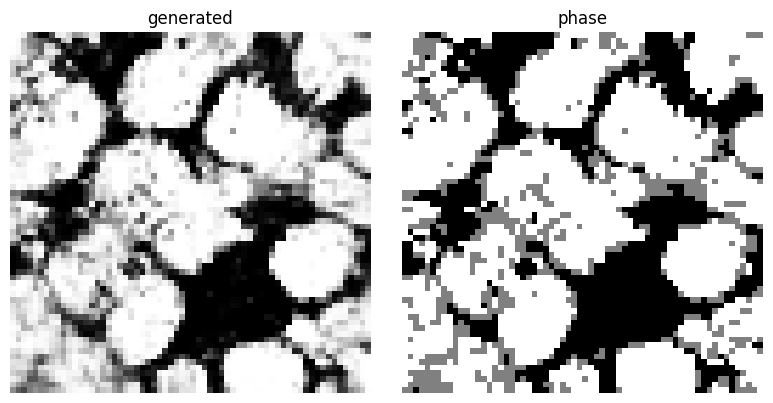

In [4]:
torch.manual_seed(SEED)
shape = (BATCH_SIZE, int(vae.latent_ch), int(vae.latent_size), int(vae.latent_size))
with torch.no_grad():
    latent = predictor.sampler.sample(shape)
    probabilities = vae.decode_probs(latent).detach().cpu()
generated = probabilities_to_relaxed_labels(probabilities, num_phases)
phase = probabilities_to_calibrated_labels(probabilities, num_phases)
phase_fraction = [(phase == value).float().mean().item() for value in range(num_phases)]
print("shape:", tuple(phase.shape))
print("phase fraction:", [round(value, 4) for value in phase_fraction])

items = [("generated", generated[0, 0], "gray", 0, num_phases - 1), ("phase", phase[0, 0], "gray", 0, num_phases - 1)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
for ax, (title, image, cmap, vmin, vmax) in zip(axes.ravel(), items):
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Critic ranking

Rank the same 2D diffusion samples by critic score. If the high-score row consistently looks more like plausible microstructure than the low-score row, the critic has transferred beyond its GAN-generator negatives.

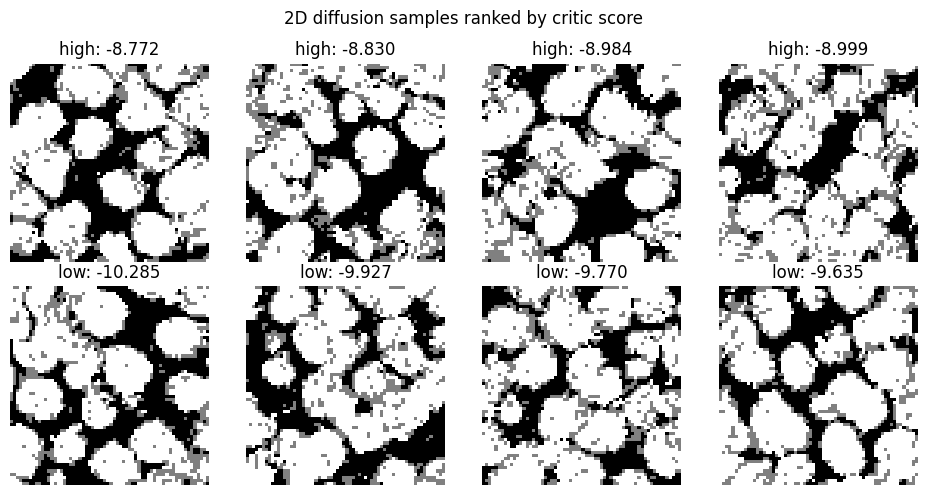

In [5]:
with torch.no_grad():
    critic_scores = critic(latent).flatten().detach().cpu()

display_count = min(DISPLAY_COUNT, BATCH_SIZE // 2)
order = critic_scores.argsort()
groups = [("high", order[-display_count:].flip(0)), ("low", order[:display_count])]

fig, axes = plt.subplots(2, display_count, figsize=(2.4 * display_count, 5), squeeze=False)
for row, (label, indices) in enumerate(groups):
    for ax, index in zip(axes[row], indices):
        ax.imshow(phase[index, 0], cmap="gray", vmin=0, vmax=num_phases - 1, interpolation="nearest")
        ax.set_title(f"{label}: {critic_scores[index]:.3f}")
        ax.axis("off")
plt.suptitle("2D diffusion samples ranked by critic score")
plt.tight_layout()

A visible separation is a quick qualitative signal, not proof of 3D guidance quality. Judge morphology rather than the numerical critic score itself.